In [8]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [9]:
path_input = '../data/'
path_output = '../figures/'

In [10]:
def compute_pdf(var, bins):

    """
    Purpose: Compute the probability density function (pdf) of a given 2D or 1D field
    ---------
    Inputs:
    ---------
    var: the snapshot or the array for the pdf
    bins: the bins axis

    
    Outputs:
    ---------
    pdf: the computed pdf in [%]
    bin_centers: the bin axis associated with the pdf
    """


    var_finite = var[np.isfinite(var)]
    hist_var, _ = np.histogram(var_finite, bins=bins)
    pdf_var = hist_var / hist_var.sum() * 100


    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return pdf_var, bin_centers

In [11]:
ds_ameda_1_8 = xr.open_dataset(path_input + 'eddy_atlas_1_8.nc')
ds_ameda_1_4 = xr.open_dataset(path_input + 'eddy_atlas_1_4.nc')

In [12]:
bin_rmax = np.linspace(0, 150, 50)
pdf_var_1_8, bin_centers = compute_pdf(ds_ameda_1_8.r_max.values, bin_rmax)
pdf_var_1_4, _ = compute_pdf(ds_ameda_1_4.r_max.values, bin_rmax)

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48079/743601150.py:3: SyntaxWarning: invalid escape sequence '\c'
  ax.plot(bin_centers, pdf_var_1_8, label = 'grid size = 1/8$^{\circ}$')
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48079/743601150.py:4: SyntaxWarning: invalid escape sequence '\c'
  ax.plot(bin_centers, pdf_var_1_4, label = 'grid size = 1/4$^{\circ}$')


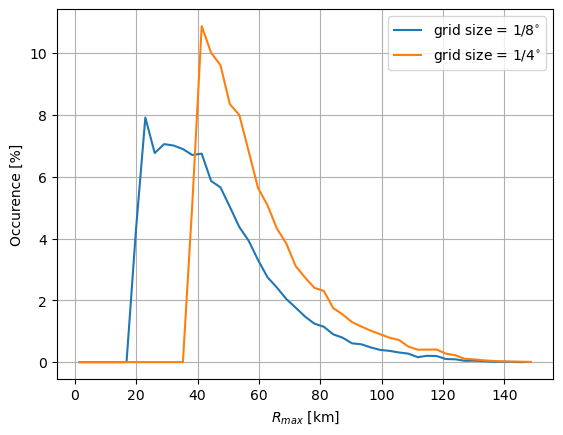

In [13]:
fig, ax = plt.subplots()

ax.plot(bin_centers, pdf_var_1_8, label = 'grid size = 1/8$^{\circ}$')
ax.plot(bin_centers, pdf_var_1_4, label = 'grid size = 1/4$^{\circ}$')
ax.set_xlabel('$R_{max}$ [km]')
ax.set_ylabel('Occurence [%]')
plt.grid()
ax.legend()
plt.savefig(path_output + 'FigS2.png', dpi = 300)